# PROCESSAMENTO DIGITAL DE IMAGENS

In [22]:
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

## TRABALHANDO IMAGENS COM PILLOW

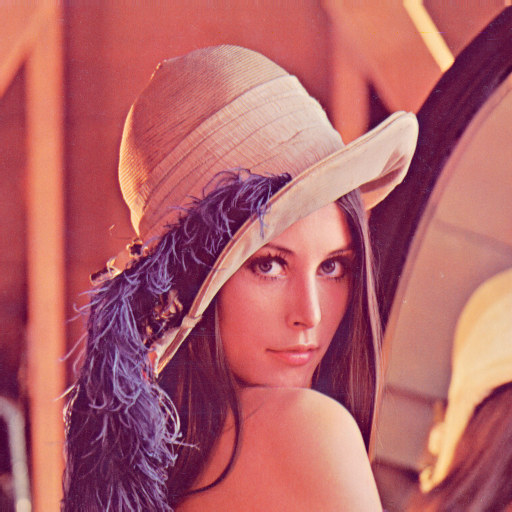

In [ ]:
# Abrindo imagem com o Pillow

lena = Image.open('images/lena.png')
lena

In [ ]:
# Visualizando caracteristicas da imagem (formato, tamanho, padrão de cores)

lena.format, lena.size, lena.mode

('PNG', (512, 512), 'RGB')

## REPRESENTAÇÃO DE UMA IMAGEM DIGITAL
![Matriz](./resources/matriz_pixels.JPG)

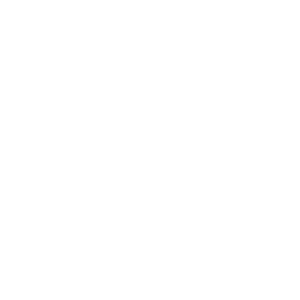

In [33]:
# Criando uma nova imagem com Pillow

pillow_image = Image.new('RGB', (300, 300), (255, 255, 255))
pillow_image

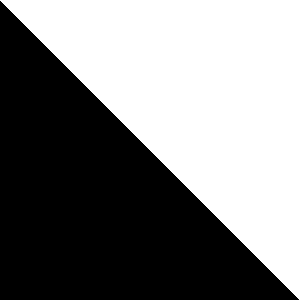

In [ ]:
# Preenchendo a imagem com < putpixel((x, y), color) >

BLACK = (0, 0, 0)

for x in range(pillow_image.size[0]):
    for y in range(pillow_image.size[0]):
        if x < y:
            pillow_image.putpixel((x, y), BLACK)
    
pillow_image

### CIRCULOS EM IMAGENS
- Proporção: 2:3 
- Preenchimento em branco
- Circulo vermelho no centro (173, 35, 51)
- Proporções do circulo:

<img src="resources/bandeira_japao.png" alt="Descrição da Imagem" width="500"/>

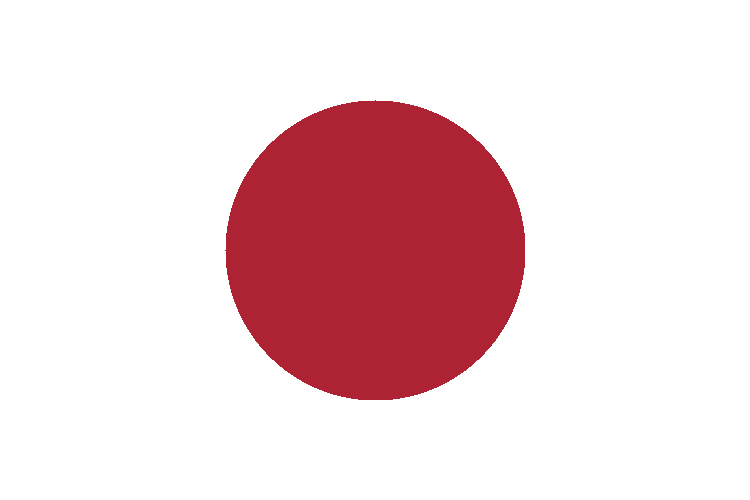

In [ ]:
# Criando a bandeira do Japão com Pillow

# Cores
WHITE = (255, 255, 255)
RED = (173, 35, 51)

# Altura e largura na proporção 2:3
height = 500
width = 3*height//2 # 750

# Criando a imagem em branco
japan = Image.new('RGB', (width, height), WHITE)

# Calculando o raio e o ponto central da imagem
radius = 3*height//10  # 150
center = (width//2, height//2) # (375, 250)

# Percorrendo o quadrado central da imagem (que fica envolta do circulo)
for x in range(center[0]-radius, center[0]+radius):
    for y in range(center[1]-radius, center[1]+radius):
        # Preenchendo o circulo central em vermelho, usando a formula:
        # (X - Cx)² + (Y - Cy)² <= R² 
        if ((x-center[0])**2 + (y-center[1])**2) <= radius**2:
            japan.putpixel((x, y), RED)

japan

## INTRODUÇÃO A IMAGENS COM OPENCV 

In [3]:
#importa a imagem
image = cv2.imread('./images/lena.png')

In [4]:
#mostra as dimensões da imagem (X, Y, Canais de Cor)
image.shape

(512, 512, 3)

In [5]:
image[0, 0]

array([125, 137, 226], dtype=uint8)

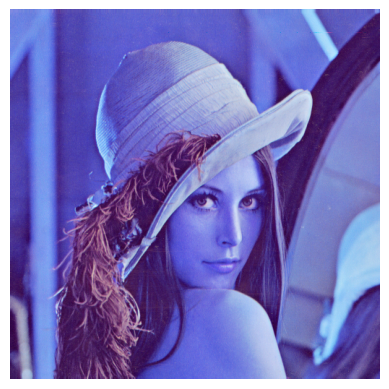

In [6]:
# Imagem no formato BGR
if image is not None:    
    plt.imshow(image)
    plt.axis('off')
    plt.show()
else:
    print('invalid image!')

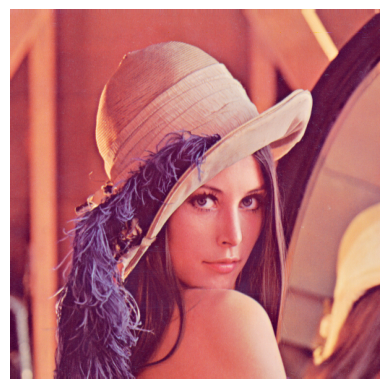

In [7]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

if image_rgb is not None:    
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.show()
else:
    print('invalid image!')

## Conversão para CMY (Cyan, Magenta, Yellow)

### Conversão de RGB para CMY

O modelo CMY é calculado subtraindo o valor RGB normalizado de 1. Isso é feito pela fórmula:

CMY é calculado usando a fórmula: CMY = 1 - (RGB / 255)

### Normalização

Multiplicamos por 255 para voltar à escala 0-255 e convertemos para o tipo `uint8` para exibição.

### Separação dos canais

Usamos `cv2.split(imagem_cmy)` para visualizar cada canal da imagem individualmente em **Ciano**, **Magenta** e **Amarelo**.




In [8]:
#Converter RGB para CMY
image_cmy = 1 - (image_rgb / 255.0)

In [9]:
#Converte CMY para escala 0-255 (para exibição)
image_cmy = (image_cmy * 255).astype(np.uint8)

In [10]:
#Divisão dos canais Cyan, Magenta, Yellow
C, M, Y = cv2.split(image_cmy)

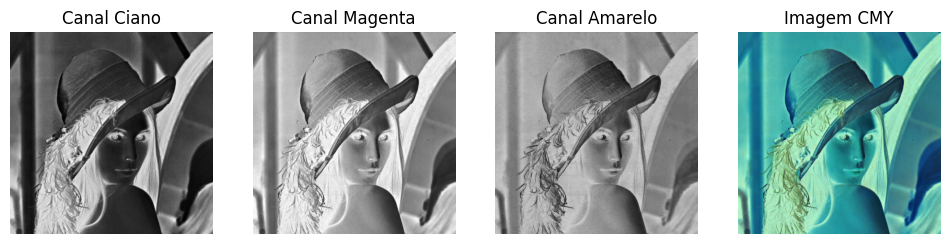

In [11]:
#Exibir os canais para visualizar a imagem em CMY
plt.figure(figsize=(12, 6))

#Canal Ciano
plt.subplot(1, 4, 1)
plt.imshow(C, cmap='gray')
plt.title('Canal Ciano')
plt.axis('off')

#Canal Magenta
plt.subplot(1, 4, 2)
plt.imshow(M, cmap='gray')
plt.title('Canal Magenta')
plt.axis('off')

#Canal Amarelo
plt.subplot(1, 4, 3)
plt.imshow(Y, cmap='gray')
plt.title('Canal Amarelo')
plt.axis('off')

#imagem CMY completa
plt.subplot(1, 4, 4)
plt.imshow(image_cmy)
plt.title('Imagem CMY')
plt.axis('off')

plt.show()

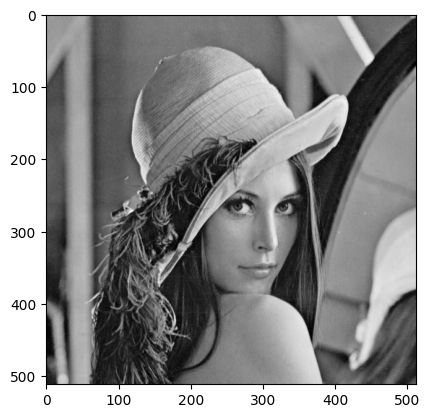

In [12]:
gray_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
plt.imshow(gray_image, cmap='gray')

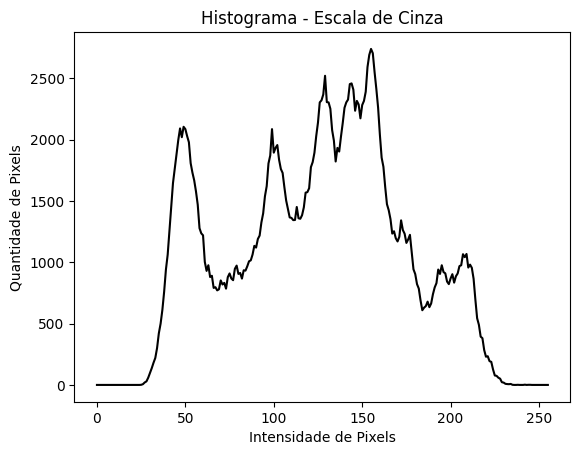

In [13]:
hist = cv2.calcHist([gray_image], [0], None, [256], [0,256])

plt.plot(hist, color='black')
plt.title('Histograma - Escala de Cinza')
plt.xlabel('Intensidade de Pixels')
plt.ylabel('Quantidade de Pixels')
plt.show()

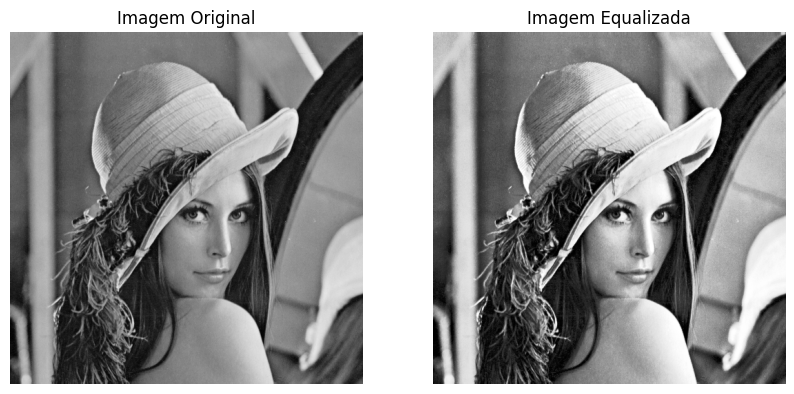

In [14]:
equalized_image = cv2.equalizeHist(gray_image)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(gray_image, cmap='gray')
plt.title('Imagem Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(equalized_image, cmap='gray')
plt.title('Imagem Equalizada')
plt.axis('off')

plt.show()

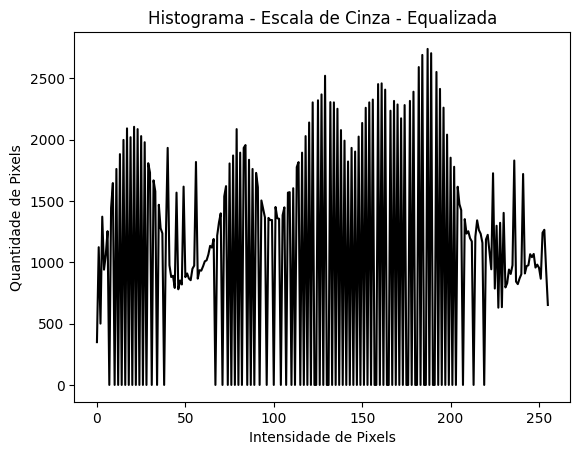

In [15]:
hist_equalized = cv2.calcHist([equalized_image], [0], None, [256], [0,256])

plt.plot(hist_equalized, color='black')
plt.title('Histograma - Escala de Cinza - Equalizada')
plt.xlabel('Intensidade de Pixels')
plt.ylabel('Quantidade de Pixels')
plt.show()